[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/anderson-perez/IAC/blob/main/Aprendizado%20Profundo/Redes_Transformer.ipynb)

# Inteligência Artificial e Computacional

## Segunda Parte da Disciplina

# Informações:

- Prof. Anderson Luiz Fernandes Perez
- Contato: anderson.perez@ufsc.br | anderson.lfp@gmail.com
- Os materiais da disciplina estarão disponíveis no github (https://github.com/anderson-perez/IAC.git)

# Fundamentos de Transformer

Redes **Transformer** são uma das arquiteturas mais importantes da Inteligência Artificial moderna, especialmente em Processamento de Linguagem Natural, Visão Computacional e modelos generativos.

Antes dos Transformers, muitos modelos de sequência usavam arquiteturas recorrentes, como:

- RNN (*Recurrent Neural Network*);
- LSTM (*Long Short-Term Memory*);
- GRU (*Gated Recurrent Unit*).

Essas redes processam sequências passo a passo. Por exemplo, em uma frase, a palavra na posição $t$ depende do estado oculto calculado na posição $t-1$.

Embora úteis, redes recorrentes possuem algumas limitações:

1. Dificuldade de paralelização, pois os elementos da sequência são processados sequencialmente.
2. Dificuldade para capturar dependências muito longas.
3. Problemas de gradiente, mesmo com arquiteturas como LSTM e GRU.

O Transformer foi apresentado no artigo **"Attention Is All You Need"**, de Vaswani et al. (2017). A ideia central foi substituir a recorrência por mecanismos de atenção.

## Ideia Central do Transformer

Um **Transformer** é uma arquitetura neural baseada principalmente em mecanismos de **atenção**.

A ideia é permitir que cada elemento de uma sequência observe diretamente os demais elementos, atribuindo pesos diferentes a cada um deles.

Por exemplo, dado a seguinte frase:

> O robô desviou do obstáculo porque ele estava no caminho.

Para entender a palavra **ele**, o modelo precisa identificar a qual termo anterior ela se refere. O mecanismo de atenção ajuda o modelo a atribuir maior importância a palavras relevantes, como **obstáculo** ou **robô**, dependendo do contexto.

Em vez de processar a frase palavra por palavra de forma recorrente, o Transformer processa todos os tokens em paralelo e calcula relações entre eles.

## Tokens

Antes de entrar no modelo, o texto é dividido em unidades chamadas **tokens**.

Um token pode ser:

- uma palavra;
- parte de uma palavra;
- um caractere;
- um símbolo especial.

Exemplo:

```text
Frase: Aprendizado profundo é interessante
Tokens possíveis: ["Aprendizado", "profundo", "é", "interessante"]
```

Em modelos modernos, é comum usar tokenização por subpalavras. Assim, palavras raras podem ser divididas em partes menores.

Por exemplo:

```text
A palavra: desnecessariamente

Tokens: des | necessária | mente
```

## Embeddings

Redes neurais não processam diretamente palavras ou símbolos. Por isso, cada token é convertido em um vetor numérico chamado **embedding**.

Se uma frase possui $n$ tokens, e cada token é representado por um vetor de dimensão $d_{model}$, a entrada do Transformer pode ser representada por uma matriz:

$$
X \in \mathbb{R}^{n \times d_{model}}
$$

onde:

- $n$ é o número de tokens;
- $d_{model}$ é a dimensão dos embeddings.

Por exemplo, se uma frase possui 10 tokens e cada embedding tem dimensão 512, então:

$$
X \in \mathbb{R}^{10 \times 512}
$$

In [1]:
import numpy as np

# Exemplo didático: 5 tokens, cada um com embedding de dimensão 4
n_tokens = 5
d_model = 4

X = np.random.randn(n_tokens, d_model)

## O problema da Posição

Ao contrário de uma RNN, o Transformer não processa os tokens em ordem temporal. Isso gera um problema: o modelo não sabe naturalmente qual token vem antes ou depois.

Por exemplo:

```text
O gato perseguiu o rato.
O rato perseguiu o gato.
```

As palavras são quase as mesmas, mas a ordem muda completamente o significado.

Para resolver isso, adiciona-se informação de posição aos embeddings. Esse mecanismo é chamado de **codificação posicional** (*positional encoding*).

## Positional Encoding

No Transformer original, a codificação posicional usa funções seno e cosseno:

$$
PE(pos, 2i) = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)
$$

$$
PE(pos, 2i+1) = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)
$$

onde:

- $pos$ é a posição do token na sequência;
- $i$ é o índice da dimensão do embedding;
- $d_{model}$ é a dimensão total do vetor.

A entrada final do Transformer é:

$$
Z = X + PE
$$

Ou seja, soma-se os embeddings dos tokens com os embeddings de posição.

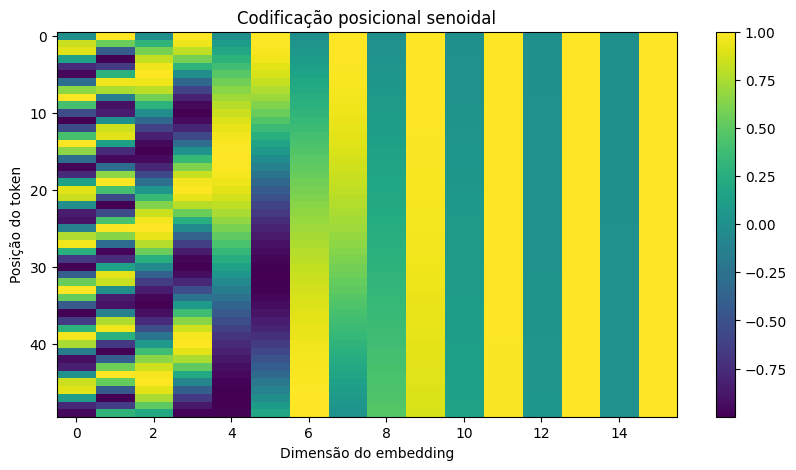

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def positional_encoding(max_len, d_model):
    pe = np.zeros((max_len, d_model))
    positions = np.arange(max_len)[:, np.newaxis]
    dims = np.arange(d_model)[np.newaxis, :]

    angle_rates = 1 / np.power(10000, (2 * (dims // 2)) / d_model)
    angles = positions * angle_rates

    pe[:, 0::2] = np.sin(angles[:, 0::2])
    pe[:, 1::2] = np.cos(angles[:, 1::2])
    return pe

pe = positional_encoding(max_len=50, d_model=16)

plt.figure(figsize=(10, 5))
plt.imshow(pe, aspect='auto')
plt.xlabel('Dimensão do embedding')
plt.ylabel('Posição do token')
plt.title('Codificação posicional senoidal')
plt.colorbar()
plt.show()

## Conceito **Intuitivo** de ATENÇÃO

Atenção é um mecanismo que permite ao modelo responder à pergunta:

> Quais partes da entrada são mais importantes para interpretar este token?

Em uma frase, cada palavra pode depender mais de algumas palavras do que de outras.

Exemplo:

```text
O sensor detectou o obstáculo e enviou o sinal para o controlador.
```

Para interpretar **sinal**, palavras como **sensor**, **detectou** e **controlador** podem ser relevantes.

O Transformer aprende automaticamente esses pesos de importância.

## Query, Key e Value

O mecanismo de atenção usa três matrizes principais:

- **Query** ($Q$): representa o que um token está procurando.
- **Key** ($K$): representa o que cada token oferece como informação para comparação.
- **Value** ($V$): representa a informação que será efetivamente combinada.

Essas matrizes são obtidas por transformações lineares da entrada:

$$
Q = XW_Q
$$

$$
K = XW_K
$$

$$
V = XW_V
$$

onde $W_Q$, $W_K$ e $W_V$ são matrizes de pesos aprendidas pelo modelo.

## Scaled Dot-Product Attention

A forma mais comum de atenção no Transformer é chamada de **Scaled Dot-Product Attention**.

A equação é:

$$
Attention(Q, K, V) = softmax\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

onde:

- $Q$ é a matriz de queries;
- $K$ é a matriz de keys;
- $V$ é a matriz de values;
- $d_k$ é a dimensão dos vetores de key;
- $QK^T$ mede similaridade entre queries e keys;
- $\sqrt{d_k}$ evita valores muito grandes antes da softmax;
- a softmax transforma os scores em pesos de atenção.

A saída é uma combinação ponderada dos valores $V$.

In [3]:
import numpy as np

def softmax(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=axis, keepdims=True)

# Exemplo simples
np.random.seed(42)
n_tokens = 4
d_k = 3

Q = np.random.randn(n_tokens, d_k)
K = np.random.randn(n_tokens, d_k)
V = np.random.randn(n_tokens, d_k)

scores = Q @ K.T / np.sqrt(d_k)
attention_weights = softmax(scores, axis=-1)
output = attention_weights @ V

print('Scores de atenção:')
print(scores)
print('\nPesos de atenção:')
print(attention_weights)
print('\nSaída da atenção:')
print(output)

Scores de atenção:
[[-0.42290045  0.03711012  0.40040782 -0.60291308]
 [ 0.70458892 -0.39998814 -0.80564302 -0.01506295]
 [-0.15958137 -1.04661163 -1.85092649  0.2102464 ]
 [ 1.05151219  0.01035465 -0.30066514  0.29430814]]

Pesos de atenção:
[[0.17551946 0.27803874 0.39983748 0.14660432]
 [0.49040487 0.16249614 0.1083102  0.23878879]
 [0.32855463 0.13532413 0.06054325 0.47557799]
 [0.48060794 0.16967661 0.12432194 0.22539351]]

Saída da atenção:
[[-0.386741    0.71366713 -0.46750158]
 [-0.52365894  0.35383064 -0.90483762]
 [-0.66747177  0.45849042 -0.99906101]
 [-0.51109401  0.36707105 -0.87951849]]


## Visualizando os Pesos de Atenção

A matriz de atenção mostra quanto cada token presta atenção nos demais tokens.

Considerando 4 tokens, a matriz de atenção terá dimensão:

$$
4 \times 4
$$

Cada linha representa um token que está "olhando" para os outros tokens. Cada coluna representa um token que está sendo observado.

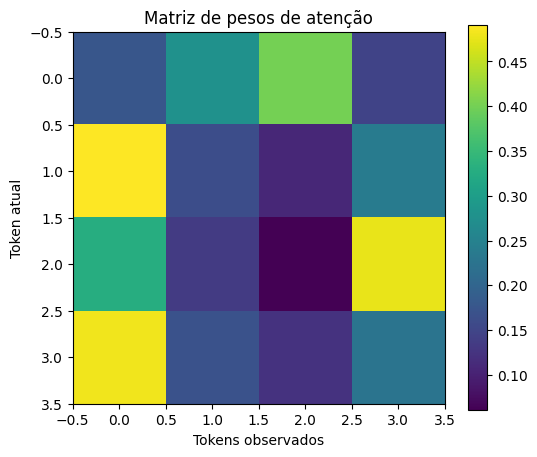

In [4]:
plt.figure(figsize=(6, 5))
plt.imshow(attention_weights)
plt.xlabel('Tokens observados')
plt.ylabel('Token atual')
plt.title('Matriz de pesos de atenção')
plt.colorbar()
plt.show()

## Self-Attention

A **self-attention** ocorre quando $Q$, $K$ e $V$ vêm da mesma sequência.

Isso significa que os tokens da sequência calculam relações entre si.

Por exemplo, em uma frase com 6 tokens, cada token pode observar os outros 5 tokens e também a si próprio.

A self-attention é o mecanismo central dos Transformers.

## Multi-Head Attention

Em vez de calcular apenas uma atenção, o Transformer calcula várias atenções em paralelo. Cada uma delas é chamada de **cabeça de atenção** (*attention head*).

A ideia é que diferentes cabeças podem aprender diferentes tipos de relação:

- relação sintática;
- relação semântica;
- dependências de longo alcance;
- relações locais;
- concordância entre sujeito e verbo;
- relações entre entidades.

Matematicamente:

$$
head_i = Attention(QW_i^Q, KW_i^K, VW_i^V)
$$

Depois, as cabeças são concatenadas:

$$
MultiHead(Q,K,V) = Concat(head_1, ..., head_h)W^O
$$

onde $h$ é o número de cabeças.

## Feedforward Network

Após a atenção, cada posição passa por uma pequena rede neural feedforward, geralmente com duas camadas lineares e uma função de ativação.

A forma geral é:

$$
FFN(x) = max(0, xW_1 + b_1)W_2 + b_2
$$

No Transformer original, a ativação usada foi ReLU. Em modelos modernos, é comum encontrar GELU ou variantes.

Essa rede é aplicada independentemente para cada token.

## Residual Connection

Transformers usam conexões residuais, semelhantes às usadas em ResNets.

Em vez de substituir completamente a entrada pela saída de uma camada, o modelo soma a entrada com a transformação realizada:

$$
Y = X + Sublayer(X)
$$

Isso facilita o treinamento de redes profundas, pois melhora o fluxo do gradiente.

## Layer Normalization

A **Layer Normalization** normaliza as ativações dentro de uma camada, ajudando na estabilidade do treinamento.

Uma estrutura comum no bloco Transformer é:

$$
LayerNorm(X + Sublayer(X))
$$

A combinação de atenção, conexão residual e normalização é fundamental para o bom funcionamento da arquitetura.

## Estrutura de um Encoder Transformer

Um bloco encoder possui, em geral:

1. Multi-Head Self-Attention.
2. Conexão residual.
3. Layer Normalization.
4. Feedforward Network.
5. Conexão residual.
6. Layer Normalization.

Representação simplificada:

```text
Entrada
  ↓
Multi-Head Self-Attention
  ↓
Add & Norm
  ↓
Feedforward Network
  ↓
Add & Norm
  ↓
Saída
```

Vários blocos encoder podem ser empilhados.

## Estrutura de um Decoder Transformer

Um bloco decoder possui três subcamadas principais:

1. Masked Multi-Head Self-Attention.
2. Cross-Attention com a saída do encoder.
3. Feedforward Network.

Representação simplificada:

```text
Entrada do decoder
  ↓
Masked Self-Attention
  ↓
Add & Norm
  ↓
Cross-Attention com o encoder
  ↓
Add & Norm
  ↓
Feedforward Network
  ↓
Add & Norm
  ↓
Saída
```

O decoder é muito usado em tarefas generativas, como tradução automática e modelos de linguagem autoregressivos.

## Máscara Causal

Em geração de texto, o modelo não pode olhar para tokens futuros.

Por exemplo, ao prever a próxima palavra em:

```text
O robô desviou do ...
```

O modelo só pode usar os tokens anteriores, não os futuros.

Para isso, usa-se uma **máscara causal** (*causal mask*), que impede a atenção a posições futuras.

Essa máscara é essencial em modelos como GPT.

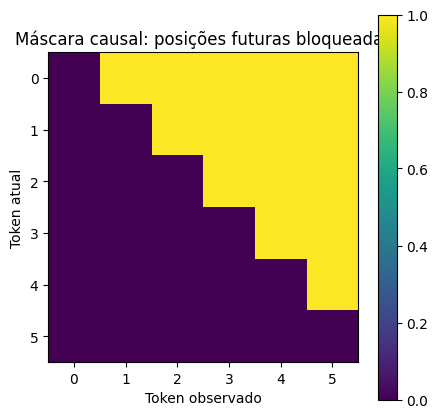

In [5]:
seq_len = 6
mask = np.triu(np.ones((seq_len, seq_len)), k=1)

plt.figure(figsize=(5, 5))
plt.imshow(mask)
plt.title('Máscara causal: posições futuras bloqueadas')
plt.xlabel('Token observado')
plt.ylabel('Token atual')
plt.colorbar()
plt.show()

## Encoder-only, decoder-only e encoder-decoder

Existem três grandes famílias de Transformers.

### Encoder-only

Usam apenas blocos encoder.

Exemplo: **BERT**.

São comuns em tarefas como:

- classificação de texto;
- análise de sentimentos;
- extração de características;
- resposta a perguntas com contexto.

### Decoder-only

Usam apenas blocos decoder com máscara causal.

Exemplo: **GPT**.

São comuns em tarefas como:

- geração de texto;
- completação de frases;
- chatbots;
- modelos autoregressivos.

### Encoder-decoder

Usam encoder e decoder.

Exemplos: **Transformer original**, **T5**, modelos de tradução.

São comuns em tarefas como:

- tradução automática;
- sumarização;
- transformação de uma sequência em outra.

# Transformer com PyTorch

**Transformer Encoder** simples para classificação de frases curtas.

A tarefa é classificar frases em duas classes:

- `0`: frase negativa
- `1`: frase positiva

O objetivo principal é entender os componentes básicos de uma rede Transformer em PyTorch.

## Bibliotecas

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

## Conjunto Simples de Dados

In [22]:
frases = [ "eu gosto de estudar",
          "pytorch é muito bom",
           "essa aula é interessante",
           "eu gosto de inteligencia artificial",
           "esse exemplo é legal",
           "eu nao gosto disso",
           "essa aula é ruim",
           "isso é muito chato",
           "nao gostei do resultado",
           "esse exemplo é dificil"
           ]

rotulos = [1, 1, 1, 1, 1, 0, 0, 0, 0, 0]

for f, r in zip(frases, rotulos):
    print(f, "->", r)

eu gosto de estudar -> 1
pytorch é muito bom -> 1
essa aula é interessante -> 1
eu gosto de inteligencia artificial -> 1
esse exemplo é legal -> 1
eu nao gosto disso -> 0
essa aula é ruim -> 0
isso é muito chato -> 0
nao gostei do resultado -> 0
esse exemplo é dificil -> 0


## Construção do Vocabulário

O Transformer não trabalha diretamente com palavras. Primeiro, cada palavra precisa ser convertida para um número inteiro.

In [23]:
# Tokenização simples por espaços
palavras = set()

for frase in frases:
    palavras.update(frase.split())

# Reservamos 0 para padding e 1 para palavras desconhecidas
vocab = {"<PAD>": 0, "<UNK>": 1}

for palavra in sorted(palavras):
    vocab[palavra] = len(vocab)

print(vocab)
print("Tamanho do vocabulário:", len(vocab))

{'<PAD>': 0, '<UNK>': 1, 'artificial': 2, 'aula': 3, 'bom': 4, 'chato': 5, 'de': 6, 'dificil': 7, 'disso': 8, 'do': 9, 'essa': 10, 'esse': 11, 'estudar': 12, 'eu': 13, 'exemplo': 14, 'gostei': 15, 'gosto': 16, 'inteligencia': 17, 'interessante': 18, 'isso': 19, 'legal': 20, 'muito': 21, 'nao': 22, 'pytorch': 23, 'resultado': 24, 'ruim': 25, 'é': 26}
Tamanho do vocabulário: 27


## Conversão de Frases para Sequências Numéricas

Como as frases têm tamanhos diferentes, é utilizado `padding` para deixá-las com o mesmo comprimento.

In [24]:
max_len = 6

def codificar_frase(frase):
    tokens = frase.split()
    ids = [vocab.get(token, vocab["<UNK>"]) for token in tokens]

    # padding
    if len(ids) < max_len:
        ids = ids + [vocab["<PAD>"]] * (max_len - len(ids))
    else:
        ids = ids[:max_len]

    return ids

X = torch.tensor([codificar_frase(frase) for frase in frases], dtype=torch.long)
y = torch.tensor(rotulos, dtype=torch.long)

print(X)
print(y)

tensor([[13, 16,  6, 12,  0,  0],
        [23, 26, 21,  4,  0,  0],
        [10,  3, 26, 18,  0,  0],
        [13, 16,  6, 17,  2,  0],
        [11, 14, 26, 20,  0,  0],
        [13, 22, 16,  8,  0,  0],
        [10,  3, 26, 25,  0,  0],
        [19, 26, 21,  5,  0,  0],
        [22, 15,  9, 24,  0,  0],
        [11, 14, 26,  7,  0,  0]])
tensor([1, 1, 1, 1, 1, 0, 0, 0, 0, 0])


## Criação do Dataset e DataLoader

In [25]:
class FrasesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


dataset = FrasesDataset(X, y)
loader = DataLoader(dataset, batch_size=2, shuffle=True)

## Codificação Posicional

O Transformer processa os tokens em paralelo. Por isso, é necessário adicionar informação sobre a posição de cada palavra na frase.

Será utilizada uma codificação posicional aprendida com `nn.Embedding`.

## Modelo Transformer Encoder

Componentes principais do modelo:

1. **Embedding de palavras**: transforma cada palavra em vetor.
2. **Embedding posicional**: adiciona informação de posição.
3. **Transformer Encoder**: aplica self-attention.
4. **Camada linear final**: realiza a classificação.

In [26]:
class TransformerClassificador(nn.Module):
    def __init__(self, vocab_size, d_model, nhead, num_layers, num_classes, max_len):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos_embedding = nn.Embedding(max_len, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=64,
            batch_first=True
        )

        self.transformer_encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.fc = nn.Linear(d_model, num_classes)

    def forward(self, x):
        batch_size, seq_len = x.shape

        # posições: 0, 1, 2, ..., seq_len-1
        posicoes = torch.arange(seq_len, device=x.device).unsqueeze(0)
        posicoes = posicoes.expand(batch_size, seq_len)

        # embedding das palavras + embedding das posições
        x = self.embedding(x) + self.pos_embedding(posicoes)

        # máscara para ignorar tokens de padding
        padding_mask = (x.abs().sum(dim=-1) == 0)

        # Transformer Encoder
        saida = self.transformer_encoder(x)

        # Usamos a média dos vetores da sequência como representação da frase
        representacao = saida.mean(dim=1)

        # Classificação final
        logits = self.fc(representacao)

        return logits

## Instanciação do Modelo

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

modelo = TransformerClassificador(
    vocab_size=len(vocab),
    d_model=32,
    nhead=4,
    num_layers=2,
    num_classes=2,
    max_len=max_len
).to(device)

print(modelo)

TransformerClassificador(
  (embedding): Embedding(27, 32, padding_idx=0)
  (pos_embedding): Embedding(6, 32)
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=64, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=64, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc): Linear(in_features=32, out_features=2, bias=True)
)


## Treinamento

In [28]:
criterio = nn.CrossEntropyLoss()
otimizador = optim.Adam(modelo.parameters(), lr=0.001)

epochs = 100

for epoch in range(epochs):
    modelo.train()
    perda_total = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        otimizador.zero_grad()

        saidas = modelo(X_batch)
        perda = criterio(saidas, y_batch)

        perda.backward()
        otimizador.step()

        perda_total += perda.item()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Perda: {perda_total:.4f}")

Epoch 10/100 - Perda: 2.3983
Epoch 20/100 - Perda: 0.1313
Epoch 30/100 - Perda: 0.0442
Epoch 40/100 - Perda: 0.0249
Epoch 50/100 - Perda: 0.0201
Epoch 60/100 - Perda: 0.0131
Epoch 70/100 - Perda: 0.0111
Epoch 80/100 - Perda: 0.0099
Epoch 90/100 - Perda: 0.0077
Epoch 100/100 - Perda: 0.0062


## Avaliação do Modelo

In [29]:
modelo.eval()

with torch.no_grad():
    X_device = X.to(device)
    saidas = modelo(X_device)
    predicoes = torch.argmax(saidas, dim=1).cpu()

for frase, real, pred in zip(frases, rotulos, predicoes):
    print(f"{frase:35s} real={real} predito={pred.item()}")

eu gosto de estudar                 real=1 predito=1
pytorch é muito bom                 real=1 predito=1
essa aula é interessante            real=1 predito=1
eu gosto de inteligencia artificial real=1 predito=1
esse exemplo é legal                real=1 predito=1
eu nao gosto disso                  real=0 predito=0
essa aula é ruim                    real=0 predito=0
isso é muito chato                  real=0 predito=0
nao gostei do resultado             real=0 predito=0
esse exemplo é dificil              real=0 predito=0


## Testando Novas Frases

In [31]:
def prever(frase):
    modelo.eval()

    ids = torch.tensor([codificar_frase(frase)], dtype=torch.long).to(device)

    with torch.no_grad():
        saida = modelo(ids)
        pred = torch.argmax(saida, dim=1).item()
        prob = torch.softmax(saida, dim=1).cpu().numpy()[0]

    classe = "positiva" if pred == 1 else "negativa"
    print(f"Frase: {frase}")
    print(f"Classe prevista: {classe}")
    print(f"Probabilidades [negativa, positiva]: {prob}")

prever("essa aula é legal")
prever("isso é chato")

Frase: essa aula é legal
Classe prevista: positiva
Probabilidades [negativa, positiva]: [0.0018321 0.9981679]
Frase: isso é chato
Classe prevista: negativa
Probabilidades [negativa, positiva]: [9.991911e-01 8.089543e-04]


# Dimensões importantes

Algumas dimensões aparecem com frequência ao estudar Transformers:

| Símbolo | Significado |
|---|---|
| $n$ | Número de tokens da sequência |
| $d_{model}$ | Dimensão do embedding principal |
| $d_k$ | Dimensão das keys e queries |
| $d_v$ | Dimensão dos values |
| $h$ | Número de cabeças de atenção |
| $d_{ff}$ | Dimensão interna da rede feedforward |

Em muitos Transformers:

$$
d_k = \frac{d_{model}}{h}
$$

Por exemplo, se $d_{model}=512$ e $h=8$, então:

$$
d_k = 64
$$

# Complexidade Computacional

A self-attention compara todos os tokens com todos os tokens.

Se a sequência tem comprimento $n$, a matriz de atenção tem dimensão:

$$
n \times n
$$

Portanto, a complexidade da atenção em relação ao tamanho da sequência é aproximadamente:

$$
O(n^2)
$$

Isso significa que sequências muito longas podem ser caras em memória e processamento.

Por esse motivo, existem variações como:

- Longformer;
- Performer;
- Linformer;
- FlashAttention;
- Transformers com atenção esparsa.

# Transformers em Visão Computacional

Transformers também podem ser usados em imagens.

O exemplo mais conhecido é o **Vision Transformer**, ou **ViT**.

A ideia é dividir a imagem em pequenos blocos chamados **patches**. Cada patch é transformado em um embedding, de forma semelhante aos tokens em texto.

Exemplo:

```text
Imagem → patches → embeddings → Transformer → classificação
```

Assim, o Transformer passa a processar a imagem como uma sequência de partes visuais.

# Principais Modelos Baseados em Transformers

| Modelo | Tipo | Uso típico |
|---|---|---|
| BERT | Encoder-only | Classificação, embeddings, QA |
| GPT | Decoder-only | Geração de texto |
| T5 | Encoder-decoder | Tradução, sumarização, conversão texto-texto |
| ViT | Encoder-only adaptado | Classificação de imagens |
| DETR | Encoder-decoder adaptado | Detecção de objetos |

A arquitetura Transformer é bastante flexível e hoje aparece em texto, imagem, áudio, código, robótica e modelos multimodais.

# Resumo Visual da Arquitetura de um Transformer

A arquitetura original do Transformer possui dois grandes blocos:

```text
              ENCODER                           DECODER
        ┌─────────────────┐              ┌────────────────────┐
Input → │ Self-Attention  │              │ Masked Attention   │ ← Output anterior
        │ Add & Norm      │              │ Add & Norm         │
        │ Feedforward     │              │ Cross-Attention    │ ← Saída do encoder
        │ Add & Norm      │              │ Add & Norm         │
        └─────────────────┘              │ Feedforward        │
                 ↓                       │ Add & Norm         │
        Representação contextual          └────────────────────┘
                                                     ↓
                                               Próximo token
```

## Glossário

| Termo | Definição |
|---|---|
| Token | Unidade de entrada do modelo, como palavra, subpalavra ou símbolo |
| Embedding | Vetor numérico que representa um token |
| Positional Encoding | Informação adicionada para indicar a posição dos tokens |
| Attention | Mecanismo que calcula a importância relativa entre tokens |
| Self-Attention | Atenção entre elementos da mesma sequência |
| Cross-Attention | Atenção entre duas sequências diferentes, como decoder olhando para encoder |
| Query | Vetor que representa o que um token procura |
| Key | Vetor usado para comparar relevância com a query |
| Value | Vetor contendo a informação que será combinada |
| Multi-Head Attention | Várias atenções calculadas em paralelo |
| Feedforward Network | Rede neural aplicada a cada posição após a atenção |
| Residual Connection | Soma da entrada com a saída de uma subcamada |
| Layer Normalization | Normalização das ativações para estabilizar o treinamento |
| Causal Mask | Máscara que impede o modelo de olhar tokens futuros |

# Referências

* Mãos à Obra: aprendizado de máquina com scikit-learn, keras & tensorflow.

* Inteligência Artificial - uma abordagem de aprendizado de máquina.

* [Deep Learning Book](https://www.deeplearningbook.com.br/)